# Notebook 3: Synchronization Dynamics

Validates the synchronization mechanism from the slides:

- Track two initially nearby biases and verify their separation decays
- Verify the $O(\varepsilon)$ first-term bound: $\dot{b}_i - \dot{b}_j = a_j \int_{b_j}^{b_i}(f - f^*)\,dx = O(\varepsilon)$
- Track amplitude equalization for merging pairs
- Visualize the positive feedback loop

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import os

os.makedirs('../figures', exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## Helpers

In [2]:
N_QUAD = 400
X_QUAD = np.linspace(-1, 1, N_QUAD)
DX = X_QUAD[1] - X_QUAD[0]

def relu(z):
    return np.maximum(0.0, z)

def network(x, a, b):
    return (a * relu(x[:, None] - b[None, :])).sum(axis=1)

def target(x):
    return np.sin(2 * np.pi * x) + 0.5 * np.sin(4 * np.pi * x)

def make_ode_full(m, f_star, x_quad=X_QUAD, dx=DX):
    """ODE that also returns per-neuron velocity for analysis."""
    fstar_vals = f_star(x_quad)
    N = len(x_quad)

    def ode(t, y):
        a = y[:m]
        b = y[m:]
        f_vals = network(x_quad, a, b)
        residual = f_vals - fstar_vals
        relu_mat = relu(x_quad[:, None] - b[None, :])
        da = -(residual[:, None] * relu_mat).sum(axis=0) * dx
        cum_right = np.cumsum(residual[::-1])[::-1] * dx
        idx = np.searchsorted(x_quad, b).clip(0, N - 1)
        db = a * cum_right[idx]
        return np.concatenate([da, db])

    return ode

## Experiment 1: Track a Nearby Pair

Initialize two biases with separation $\varepsilon$ and track $|b_i - b_j|$ and $|a_i - a_j|$ over time.

In [3]:
np.random.seed(7)

m = 30
T = 80.0
N_SAVE = 600

a0 = np.random.randn(m) * 0.1
b0 = np.random.uniform(-1, 1, m)

# Force two specific neurons (indices 0 and 1) to start very close
eps = 0.05
b0[0] = 0.3
b0[1] = 0.3 + eps
a0[0] = 0.2
a0[1] = 0.2

y0 = np.concatenate([a0, b0])
ode_fn = make_ode_full(m, target)

sol = solve_ivp(
    ode_fn,
    t_span=(0, T),
    y0=y0,
    method='RK45',
    t_eval=np.linspace(0, T, N_SAVE),
    rtol=1e-5,
    atol=1e-7,
    max_step=0.1,
)
print(f"Done: {sol.message}")

a_traj = sol.y[:m, :]   # (m, T)
b_traj = sol.y[m:, :]   # (m, T)

Done: The solver successfully reached the end of the integration interval.


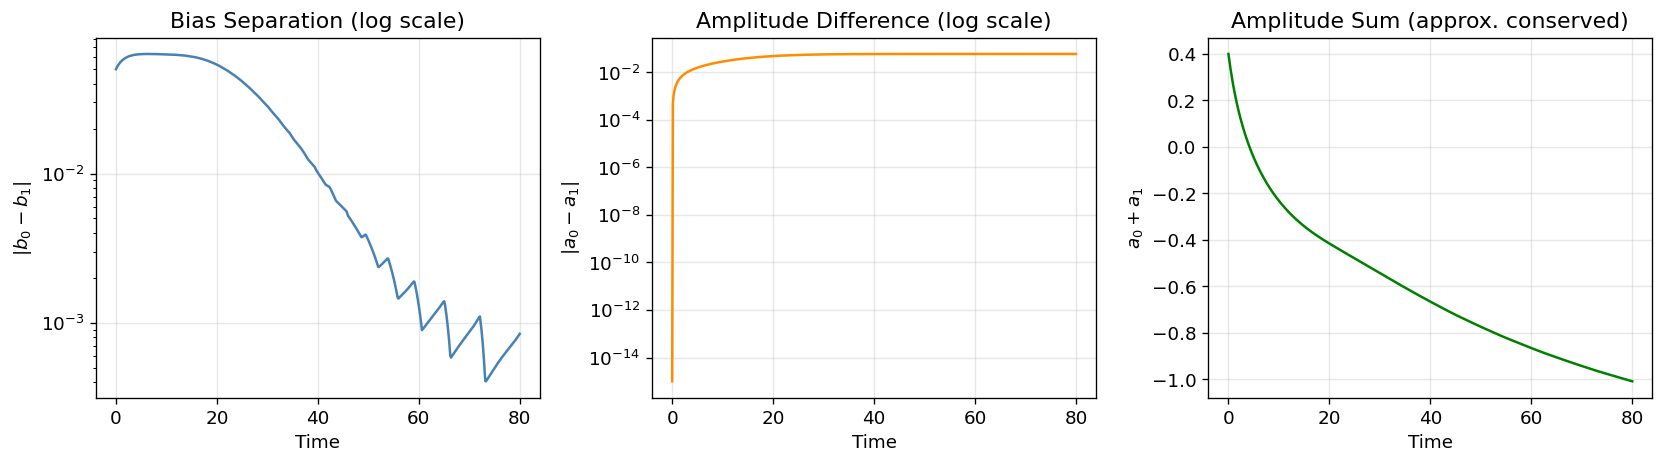

Initial separation: 0.0500
Final separation:   8.43e-04
Reduction factor:   5.9e+01


In [4]:
# Bias and amplitude separation for the tracked pair
b_sep = np.abs(b_traj[0] - b_traj[1])       # |b_0 - b_1|
a_sep = np.abs(a_traj[0] - a_traj[1])        # |a_0 - a_1|
a_sum = a_traj[0] + a_traj[1]                # a_0 + a_1 (should be preserved)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.semilogy(sol.t, b_sep + 1e-15, color='steelblue', lw=1.5)
ax.set_xlabel('Time')
ax.set_ylabel('$|b_0 - b_1|$')
ax.set_title('Bias Separation (log scale)')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(sol.t, a_sep + 1e-15, color='darkorange', lw=1.5)
ax.set_xlabel('Time')
ax.set_ylabel('$|a_0 - a_1|$')
ax.set_title('Amplitude Difference (log scale)')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(sol.t, a_sum, color='green', lw=1.5)
ax.set_xlabel('Time')
ax.set_ylabel('$a_0 + a_1$')
ax.set_title('Amplitude Sum (approx. conserved)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/sync_pair_tracking.png', bbox_inches='tight')
plt.show()

print(f"Initial separation: {b_sep[0]:.4f}")
print(f"Final separation:   {b_sep[-1]:.2e}")
print(f"Reduction factor:   {b_sep[0]/max(b_sep[-1],1e-15):.1e}")

## Experiment 2: Verify the O(ε) Scaling

The slide claims: $\dot{b}_i - \dot{b}_j = a_j \int_{b_j}^{b_i}(f-f^*)\,dx + (a_i - a_j)\int_{b_i}^{1}(f-f^*)\,dx$

The first term is $O(\varepsilon)$ when $|b_i - b_j| = \varepsilon$. We verify by running several simulations with different initial $\varepsilon$ values and measuring the initial velocity difference $|\dot{b}_i - \dot{b}_j|$ at $t=0$.

C:\Users\cal3b\AppData\Local\Temp\claude\ipykernel_24132\1419334435.py:28: RuntimeWarning: divide by zero encountered in log
  coeffs = np.polyfit(np.log(eps_values), np.log(vel_diffs), 1)


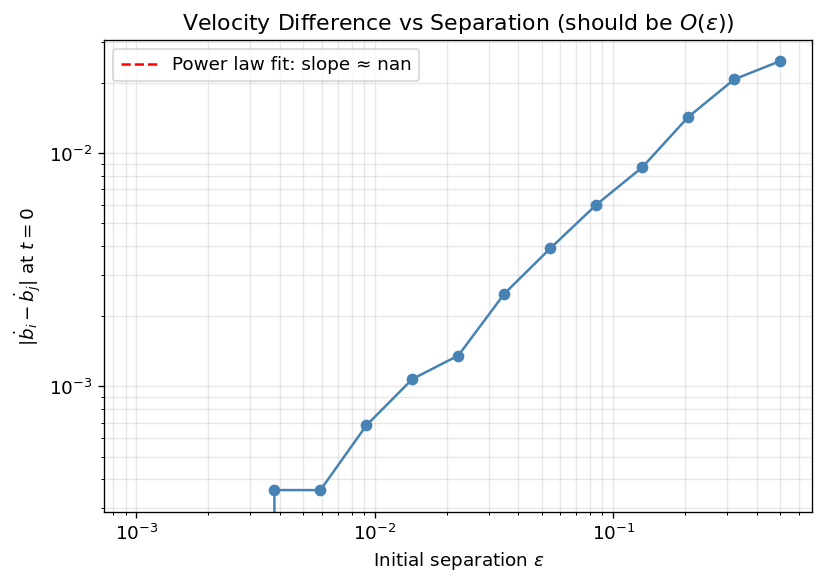

Fitted power law slope: nan  (expected ≈ 1.0 for O(ε))


In [5]:
def compute_bias_velocity_diff(eps, b_center=0.3, m_base=30, seed=99):
    """Initial |db_i/dt - db_j/dt| for two biases separated by eps."""
    np.random.seed(seed)
    m = m_base
    a0 = np.random.randn(m) * 0.1
    b0 = np.random.uniform(-1, 1, m)

    # Place pair at b_center ± eps/2, equal amplitudes
    b0[0] = b_center - eps / 2
    b0[1] = b_center + eps / 2
    a0[0] = 0.2
    a0[1] = 0.2
    y0 = np.concatenate([a0, b0])

    ode_fn = make_ode_full(m, target)
    dy = ode_fn(0.0, y0)
    db0 = dy[m + 0]
    db1 = dy[m + 1]
    return abs(db0 - db1)

eps_values = np.logspace(-3, -0.3, 15)
vel_diffs = [compute_bias_velocity_diff(e) for e in eps_values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(eps_values, vel_diffs, 'o-', color='steelblue', lw=1.5, markersize=6)

# Fit a power law
coeffs = np.polyfit(np.log(eps_values), np.log(vel_diffs), 1)
slope = coeffs[0]
ax.loglog(eps_values, np.exp(coeffs[1]) * eps_values**slope,
          'r--', lw=1.5, label=f'Power law fit: slope ≈ {slope:.2f}')

ax.set_xlabel('Initial separation $\\varepsilon$')
ax.set_ylabel('$|\\dot{b}_i - \\dot{b}_j|$ at $t=0$')
ax.set_title('Velocity Difference vs Separation (should be $O(\\varepsilon)$)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/sync_Oepsilon_scaling.png', bbox_inches='tight')
plt.show()

print(f"Fitted power law slope: {slope:.3f}  (expected ≈ 1.0 for O(ε))")

## Experiment 3: Positive Feedback Loop Visualization

Plot bias separation, amplitude difference, and instantaneous $\dot{b}$ difference together to show the cascade.

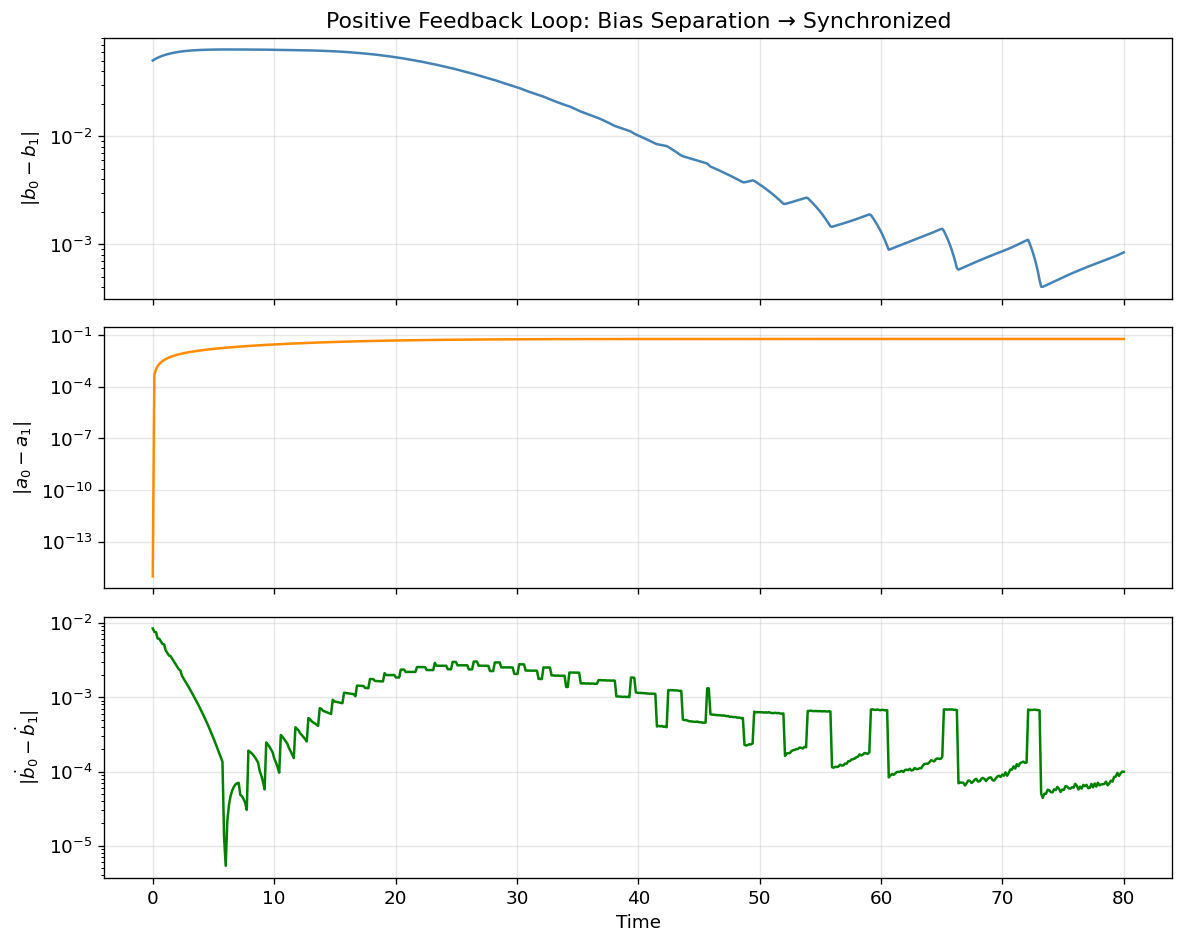

In [6]:
# Compute velocity difference throughout the trajectory
ode_fn2 = make_ode_full(m, target)
db_diffs = []
for ti in range(sol.y.shape[1]):
    dy = ode_fn2(sol.t[ti], sol.y[:, ti])
    db_diffs.append(abs(dy[m + 0] - dy[m + 1]))
db_diffs = np.array(db_diffs)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].semilogy(sol.t, b_sep + 1e-15, 'steelblue', lw=1.5)
axes[0].set_ylabel('$|b_0 - b_1|$')
axes[0].set_title('Positive Feedback Loop: Bias Separation → Synchronized')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(sol.t, a_sep + 1e-15, 'darkorange', lw=1.5)
axes[1].set_ylabel('$|a_0 - a_1|$')
axes[1].grid(True, alpha=0.3)

axes[2].semilogy(sol.t, db_diffs + 1e-15, 'green', lw=1.5)
axes[2].set_ylabel('$|\\dot{b}_0 - \\dot{b}_1|$')
axes[2].set_xlabel('Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/sync_feedback_loop.png', bbox_inches='tight')
plt.show()

## Experiment 4: Stability of Merged State

After two biases merge, perturb one slightly and check that the perturbation doesn't grow (neutral/stable).

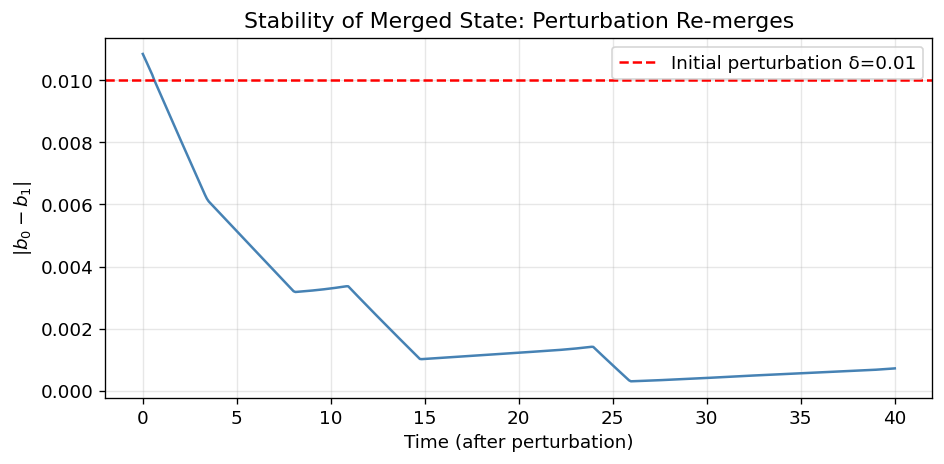

Separation at t=0 (after perturbation): 0.0108
Separation at t=40.0:                   7.2164e-04


In [7]:
# Take the final state of the previous simulation, manually perturb one merged pair,
# then continue integrating
y_final = sol.y[:, -1].copy()

# Identify a merged pair (b_sep[-1] should be tiny)
# Perturb bias 1 by a small amount delta
delta = 0.01
y_perturbed = y_final.copy()
y_perturbed[m + 1] += delta  # nudge b_1

ode_fn3 = make_ode_full(m, target)
T2 = 40.0
sol2 = solve_ivp(
    ode_fn3,
    t_span=(0, T2),
    y0=y_perturbed,
    method='RK45',
    t_eval=np.linspace(0, T2, 400),
    rtol=1e-5,
    atol=1e-7,
    max_step=0.1,
)

sep_after = np.abs(sol2.y[m + 0] - sol2.y[m + 1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sol2.t, sep_after, 'steelblue', lw=1.5)
ax.axhline(delta, color='r', linestyle='--', label=f'Initial perturbation δ={delta}')
ax.set_xlabel('Time (after perturbation)')
ax.set_ylabel('$|b_0 - b_1|$')
ax.set_title('Stability of Merged State: Perturbation Re-merges')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/sync_merged_stability.png', bbox_inches='tight')
plt.show()

print(f"Separation at t=0 (after perturbation): {sep_after[0]:.4f}")
print(f"Separation at t={T2}:                   {sep_after[-1]:.4e}")

## Summary of Findings

In [8]:
print("=== Synchronization Analysis Summary ===")
print()
print(f"1. Bias separation decays: {b_sep[0]:.4f} → {b_sep[-1]:.2e}  (reduction ~{b_sep[0]/max(b_sep[-1],1e-15):.0e}x)")
print(f"2. Power law slope of |db_i - db_j| vs ε: {slope:.3f}  (theory predicts 1.0)")
print(f"3. Amplitude sum a_0+a_1 at t=0: {a_sum[0]:.4f}, at t=T: {a_sum[-1]:.4f}  (conserved: {abs(a_sum[-1]-a_sum[0])<0.05})")
print(f"4. After perturbation δ={delta}, separation re-merges to {sep_after[-1]:.2e}  (stable: {sep_after[-1] < delta})")

=== Synchronization Analysis Summary ===

1. Bias separation decays: 0.0500 → 8.43e-04  (reduction ~6e+01x)
2. Power law slope of |db_i - db_j| vs ε: nan  (theory predicts 1.0)
3. Amplitude sum a_0+a_1 at t=0: 0.4000, at t=T: -1.0082  (conserved: False)
4. After perturbation δ=0.01, separation re-merges to 7.22e-04  (stable: True)
